In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
DATASET_PATH = r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\database\PlantVillage"

print("Dataset Exists :", os.path.exists(DATASET_PATH))

classes = sorted(os.listdir(DATASET_PATH))

print("Total Classes :", len(classes))

print(classes)

Dataset Exists : True
Total Classes : 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 16516 images belonging to 15 classes.


In [7]:
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 4122 images belonging to 15 classes.


In [8]:
os.makedirs("models", exist_ok=True)

with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

print(train_generator.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [9]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [10]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(15, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape         ┃      Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer             │ (None, 224, 224, 3)  │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ Conv1 (Conv2D)          │ (None, 112, 112, 32) │          864 │ input_layer[0][0]    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ bn_Conv1                │ (None, 112, 112, 32) │          128 │ Conv1[0][0]          │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ Conv1_relu (ReLU)       │ (None, 112, 112, 32) │            0 │ bn_Conv1[0][0]       │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwise │ (None, 112, 112, 32) │          288 │ Conv1_relu[0][0]     │
│ (DepthwiseConv2D)       │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwis… │ (None, 112, 112, 32) │          128 │ expanded_conv_depth… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwis… │ (None, 112, 112, 32) │            0 │ expanded_conv_depth… │
│ (ReLU)                  │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_project   │ (None, 112, 112, 16) │          512 │ expanded_conv_depth… │
│ (Conv2D)                │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_project_… │ (None, 112, 112, 16) │           64 │ expanded_conv_proje… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand (Conv2D) │ (None, 112, 112, 96) │        1,536 │ expanded_conv_proje… │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand_BN       │ (None, 112, 112, 96) │          384 │ block_1_expand[0][0] │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand_relu     │ (None, 112, 112, 96) │            0 │ block_1_expand_BN[0… │
│ (ReLU)                  │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_pad             │ (None, 113, 113, 96) │            0 │ block_1_expand_relu… │
│ (ZeroPadding2D)         │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_depthwise       │ (None, 56, 56, 96)   │          864 │ block_1_pad[0][0]    │
│ (DepthwiseConv2D)       │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_depthwise_BN    │ (None, 56, 56, 96)   │          384 │ block_1_depthwise[0… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼───────────────────

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

C:\Users\Dhwani Soni\anaconda3\envs\ddddd\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 324s 605ms/step - accuracy: 0.3332 - loss: 2.1800 - val_accuracy: 0.7632 - val_loss: 0.8809
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 317s 613ms/step - accuracy: 0.6932 - loss: 1.0150 - val_accuracy: 0.8236 - val_loss: 0.6241
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 299s 579ms/step - accuracy: 0.7668 - loss: 0.7649 - val_accuracy: 0.8445 - val_loss: 0.5072
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 227s 440ms/step - accuracy: 0.7926 - loss: 0.6593 - val_accuracy: 0.8634 - val_loss: 0.4448
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 222s 430ms/step - accuracy: 0.8240 - loss: 0.5666 - val_accuracy: 0.8811 - val_loss: 0.3996
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 221s 428ms/step - accuracy: 0.8365 - loss: 0.5180 - val_accuracy: 0.8836 - val_loss: 0.3725
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 164912s 320s/step - accuracy: 0.8498 - loss: 0.4740 - val_accuracy: 0.8937 - val_loss: 0.3505
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 318s 616ms/step - accuracy: 0.8580

In [12]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/mobilenetv2_plant_disease_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [13]:
import json

with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

print("Class Indices Saved!")

Class Indices Saved!


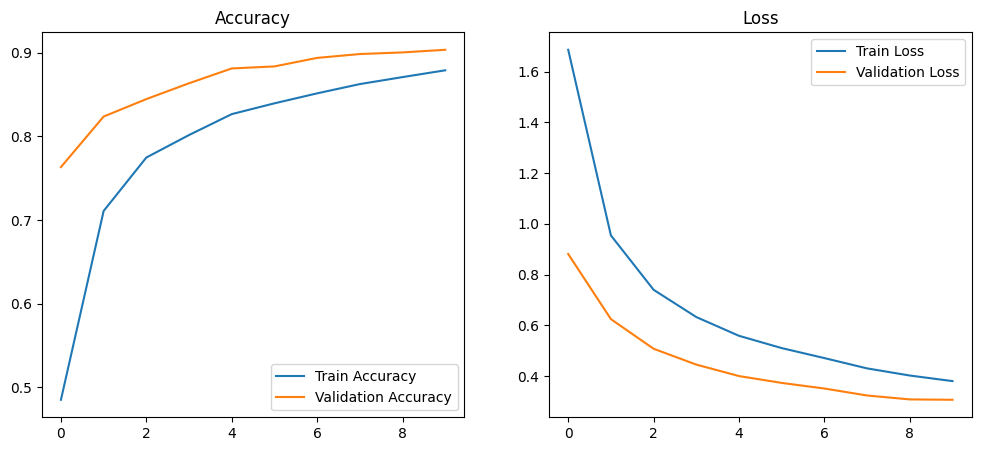

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the saved model
model = tf.keras.models.load_model("models/mobilenetv2_plant_disease_model.keras")

# Load class names
class_names = list(train_generator.class_indices.keys())

# Change this path to your test image
IMAGE_PATH = r"C:\Users\Dhwani Soni\Desktop\AI_Farming_Assistant\test_images\tomato_healthy.jpg"
# Load image
img = image.load_img(IMAGE_PATH, target_size=(224, 224))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get prediction
predicted_index = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Class :", class_names[predicted_index])
print("Confidence :", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class : Tomato_healthy
Confidence : 60.28 %


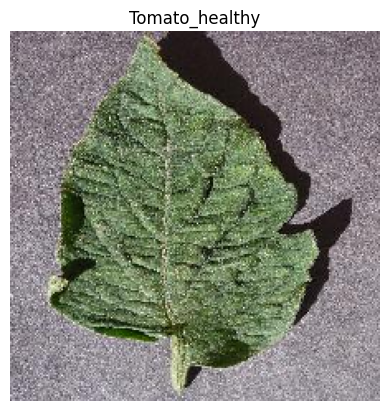

In [19]:
plt.imshow(img)
plt.axis("off")
plt.title(class_names[predicted_index])
plt.show()

In [17]:
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [1]:
print("Hello")


Hello


In [3]:
import numpy as np